In [1]:
from typing import Tuple

import torch 
from torch import Tensor

import deep_tensor as dt

from examples.sir import SIRCompartmentModel
from examples.plotting import add_arrows, set_plot_style

In [2]:
torch.manual_seed(0)
torch.set_default_device("cuda" if torch.cuda.is_available() else "cpu")
set_plot_style()

In [ ]:
def build_adjacency_matrix(K: int) -> torch.Tensor:
    A = torch.zeros((K, K))
    for i in range(K):
        A[i][(i-1)%K] = 1
        A[i][(i+1)%K] = 1
    return A

# Define rare event threshold
I_max = 88.0


compartments = [3, 5, 6, 8, 12, 16]
dims = [2*c for c in compartments]

num_compartments = len(compartments)
num_runs = 10

probs = torch.zeros((num_compartments, num_runs))
num_evals = torch.zeros((num_compartments, num_runs))
dhell_numerators = torch.zeros((num_compartments, num_runs))
dhell_denominators = torch.zeros((num_compartments, num_runs))

for i, num_compartments in enumerate(compartments):

    print(f"compartments: {num_compartments}")

    # num_compartments = 8
    dim = 2 * num_compartments

    adjacency_matrix = build_adjacency_matrix(num_compartments)

    S0 = torch.arange(100-num_compartments, 100)
    I0 = 100 - S0
    R0 = torch.zeros((num_compartments,))

    # Define timespan and evaluation times
    t1 = 5.0
    t_eval = torch.linspace(0, 5, 25*6+1)
    inds_obs = torch.arange(0, 25*6+1, 25)

    model = SIRCompartmentModel(adjacency_matrix, S0, I0, R0, t_eval, inds_obs)

    true_param = torch.tensor([[0.1, 1.0] * num_compartments])

    # Properties of likelihood
    std_noise = 1.0

    ys_true = model.get_obs(model.solve(true_param))
    ys_obs = ys_true # + std_noise * torch.randn_like(ys_true)


    def neglogpost(xs: Tensor) -> Tensor:
        # Note: prior is uniform
        ys = model.get_obs(model.solve(xs))
        neglogliks = (ys-ys_obs).square().sum(dim=1) / (2*std_noise**2)
        return neglogliks

    def rare_event_func(xs: Tensor) -> Tuple[Tensor, Tensor]:

        ys_full = model.solve(xs)
        ys = model.get_obs(ys_full)

        neglogliks = (ys-ys_obs).square().sum(dim=1) / (2*std_noise**2)
        response = model.response_func(ys_full)

        return neglogliks, response

    for j in range(num_runs):

        print(f"Run {j+1}")

        domain = dt.BoundedDomain([-3.0, 3.0])
        reference = dt.GaussianReference(domain)
        bounds = torch.tensor([[0.0, 2.0]]).tile((dim, 1))
        preconditioner = dt.UniformMapping(bounds=bounds, reference=reference)

        basis = dt.Lagrange1(num_elems=16)
        # basis = dt.Fourier(order=8)
        # basis = dt.Legendre(order=17)

        tt_options = dt.TTOptions(max_als=1, init_rank=7, tt_method="fixed_rank", verbose=0)

        tt = dt.TT(tt_options)
        ftt = dt.FTT(bases, tt, num_error_samples=0)

        dirt_options = dt.DIRTOptions(num_error_samples=0)

        # Numerator

        rare_event = dt.RareEventFunc(rare_event_func, threshold=I_max)

        betas = 10 ** torch.linspace(-4.0, 0.0, 13)
        gamma_prime = 3.3e+3 / I_max
        gammas = betas * gamma_prime
        bridge = dt.GaussianSmoothing(gammas, betas)

        numerator = dt.DIRT(rare_event, preconditioner, ftt, bridge, dirt_options)

        # Denominator

        betas = 10 ** torch.linspace(-4.0, 0.0, 13)
        betas = betas.tolist()
        bridge = dt.Tempering(betas)

        posterior = dt.TargetFunc(neglogpost)

        denominator = dt.DIRT(posterior, preconditioner, ftt, bridge, dirt_options)

        num_samples = 10_000

        rs = numerator.reference.random(num_samples, dim)
        xs, neglogfxs_dirt = numerator.eval_irt(rs)
        neglogfxs_exact = rare_event(xs)
        dhell_numerator = dt.compute_f_divergence(-neglogfxs_dirt, -neglogfxs_exact).sqrt()

        Q_is = dt.run_importance_sampling(neglogfxs_dirt, neglogfxs_exact)
        Q_hat = Q_is.log_weights.exp().mean()

        rs = denominator.reference.random(num_samples, dim)
        xs, neglogfxs_dirt = denominator.eval_irt(rs)
        neglogfxs_exact = posterior(xs)
        dhell_denominator = dt.compute_f_divergence(-neglogfxs_dirt, -neglogfxs_exact).sqrt()

        Z_is = dt.run_importance_sampling(neglogfxs_dirt, neglogfxs_exact)
        Z_hat = Z_is.log_weights.exp().mean()

        R_hat = Q_hat / Z_hat

        print(f"Estimated event probability: {R_hat:.4e}.")
        print(f"Total density evaluations (numerator): {numerator.num_eval_construction}.")
        print(f"Total density evaluations (denominator): {denominator.num_eval_construction}.")

        probs[i][j] = R_hat
        num_evals[i][j] = numerator.num_eval_construction + denominator.num_eval_construction
        dhell_numerators[i][j] = dhell_numerator
        dhell_denominators[i][j] = dhell_denominator

compartments: 3
Run 1
[DIRT] Iter:  1 | Cum. Fevals: 0.00e+00 | Cum. Time: 9.54e-07 s | Gamma: 0.0038 | Beta: 0.0001
[DIRT] Iter:  2 | Cum. Fevals: 3.57e+03 | Cum. Time: 5.17e+00 s | Gamma: 0.0081 | Beta: 0.0002
[DIRT] Iter:  3 | Cum. Fevals: 7.14e+03 | Cum. Time: 1.04e+01 s | Gamma: 0.0174 | Beta: 0.0005
[DIRT] Iter:  4 | Cum. Fevals: 1.07e+04 | Cum. Time: 1.40e+01 s | Gamma: 0.0375 | Beta: 0.0010
[DIRT] Iter:  5 | Cum. Fevals: 1.43e+04 | Cum. Time: 1.78e+01 s | Gamma: 0.0808 | Beta: 0.0022
[DIRT] Iter:  6 | Cum. Fevals: 1.78e+04 | Cum. Time: 2.12e+01 s | Gamma: 0.1741 | Beta: 0.0046
[DIRT] Iter:  7 | Cum. Fevals: 2.14e+04 | Cum. Time: 2.44e+01 s | Gamma: 0.3750 | Beta: 0.0100
[DIRT] Iter:  8 | Cum. Fevals: 2.50e+04 | Cum. Time: 2.75e+01 s | Gamma: 0.8079 | Beta: 0.0215
[DIRT] Iter:  9 | Cum. Fevals: 2.86e+04 | Cum. Time: 3.02e+01 s | Gamma: 1.7406 | Beta: 0.0464
[DIRT] Iter: 10 | Cum. Fevals: 3.21e+04 | Cum. Time: 3.30e+01 s | Gamma: 3.7500 | Beta: 0.1000
[DIRT] Iter: 11 | Cum. Feval

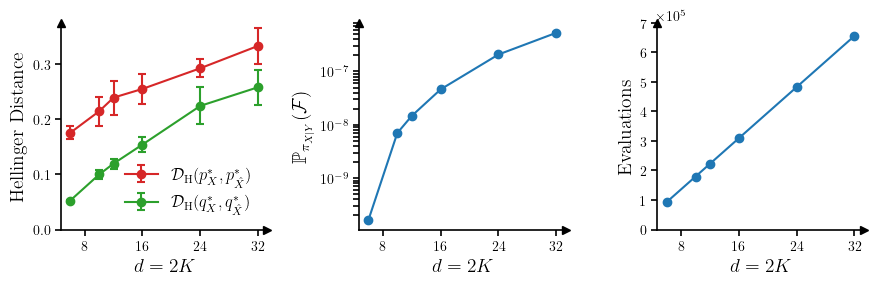

In [15]:
from matplotlib import pyplot as plt

plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{amsfonts, bm}"
})

error_kwargs = {
    "fmt": "-o",
    "markersize": 6,
    "linewidth": 1.5,
    "elinewidth": 1.5,
    "capsize": 3.0,
    "capthick": 1.5,
}

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))

axes[0].errorbar(
    dims, dhell_numerators.mean(dim=1), 
    yerr=dhell_numerators.std(dim=1), 
    **error_kwargs, c="tab:red",
    label=r"$\mathcal{D}_{\mathrm{H}}(p^{*}_{X}, p^{*}_{\hat{X}})$"
)
axes[0].errorbar(
    dims, dhell_denominators.mean(dim=1), 
    yerr=dhell_denominators.std(dim=1), 
    **error_kwargs, c="tab:green",
    label=r"$\mathcal{D}_{\mathrm{H}}(q^{*}_{X}, q^{*}_{\hat{X}})$"
)
axes[0].set_ylabel("Hellinger Distance")
axes[0].legend()
axes[0].set_ylim((0.0, 0.375))

axes[1].errorbar(
    dims, probs.mean(dim=1), 
    yerr=probs.std(dim=1),
    **error_kwargs
)
axes[1].set_yscale("log")
# \mathbb{P}
axes[1].set_ylabel(r"$\mathbb{P}_{\pi_{X|Y}}(\mathcal{F})$")

axes[2].errorbar(
    dims, 
    2*num_evals.mean(dim=1), 
    yerr=num_evals.std(dim=1),
    **error_kwargs
)
axes[2].set_ylabel("Evaluations")
axes[2].ticklabel_format(axis="y", scilimits=(0, 0))
axes[2].set_ylim((0, 700_000))

for ax in axes:
    add_arrows(ax)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$d=2K$")
    ax.set_xticks([8, 16, 24, 32])

plt.tight_layout()
plt.savefig("estimates.pdf")